## 1. Imports and Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings
from tqdm import tqdm
warnings.filterwarnings("ignore")


# Paths
# BASE_DIR = "../data"
BASE_DIR = "/content/drive/MyDrive/209b/209b_project/data"
CSV_PATH  = os.path.join(BASE_DIR, "artists.csv")
IMG_DIR   = os.path.join(BASE_DIR, "resized")

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Libraries loaded.")
print(f"Image directory: {IMG_DIR}")
print(f"Total images: {len(os.listdir(IMG_DIR))}")



Libraries loaded.
Image directory: /content/drive/MyDrive/209b/209b_project/data/resized
Total images: 8355


In [3]:
df = pd.read_csv(CSV_PATH)
img_files = os.listdir(IMG_DIR)

In [4]:
def parse_years(years_str):
    parts = str(years_str).split(" - ")
    birth = int(parts[0].strip()) if parts[0].strip().isdigit() else None
    death = int(parts[1].strip()) if len(parts) > 1 and parts[1].strip().isdigit() else None
    return birth, death

df[["birth_year", "death_year"]] = df["years"].apply(
    lambda y: pd.Series(parse_years(y))
)
img_counts = Counter("_".join(f.split("_")[:-1]) for f in img_files if f.endswith(".jpg"))

# Map to CSV name (spaces → underscores)
df["name_key"] = df["name"].str.replace(" ", "_")
df["img_count_disk"] = df["name_key"].map(img_counts).fillna(0).astype(int)

df["genre_list"] = df["genre"].apply(lambda g: [x.strip() for x in str(g).split(",")])

---
## 2. Baseline Image Classification Model

Fine-tune a pretrained ResNet-18 to predict artist identity (50-class classification).  
We freeze the backbone and only train the final classifier head as a fast baseline.

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import time

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")
print(f"Using device: {device}")

# Build name_key -> name lookup from df
name_key_to_name = dict(zip(df["name_key"], df["name"]))

all_paths, all_labels = [], []
for fname in sorted(img_files):
    if not fname.endswith(".jpg"):
        continue
    name_key = "_".join(fname.split("_")[:-1])
    name = name_key_to_name.get(name_key)
    if name is None:
        continue
    all_paths.append(os.path.join(IMG_DIR, fname))
    all_labels.append(name)


le = LabelEncoder()
all_labels_enc = le.fit_transform(all_labels)
n_classes = len(le.classes_)
print(f"Total images: {len(all_paths)}, Classes: {n_classes}")

# Train / val / test split (stratified)
X_tv, X_test, y_tv, y_test = train_test_split(
    all_paths, all_labels_enc, test_size=0.10, stratify=all_labels_enc, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.111, stratify=y_tv, random_state=42)
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# ImageNet normalization (matches pretrained weights)
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

Using device: cuda
Total images: 8027, Classes: 49
Train: 6422, Val: 802, Test: 803


In [6]:
class ArtDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]

# Weighted sampler to handle class imbalance
label_counts = np.bincount(y_train)
weights = 1.0 / label_counts[y_train]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_ds  = ArtDataset(X_train, y_train, train_tf)
val_ds    = ArtDataset(X_val,   y_val,   val_tf)
test_ds   = ArtDataset(X_test,  y_test,  val_tf)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False,   num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False,   num_workers=0)

In [7]:
# Load pretrained ResNet-18, replace final FC layer
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all backbone layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head (trainable)
model.fc = nn.Linear(model.fc.in_features, n_classes)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


Trainable params: 25,137 / 11,201,649


In [20]:
HISTORY_PATH  = "resnet18_history.npy"
MODEL_PATH    = "resnet18_artist.pt"
CKPT_PATH     = "resnet18_checkpoint.pt"   # per-epoch checkpoint
N_EPOCHS      = 10

if os.path.exists(HISTORY_PATH) and os.path.exists(MODEL_PATH):
    print("Found saved model and history, loading...")
    history = np.load(HISTORY_PATH, allow_pickle=True).item()
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"Loaded. Epochs recorded: {len(history['val_acc'])}")
else:
    def run_epoch(loader, train=True):
        model.train() if train else model.eval()
        total_loss, correct = 0.0, 0
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out  = model(imgs)
                loss = criterion(out, labels)
                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                total_loss += loss.item() * len(imgs)
                correct    += (out.argmax(1) == labels).sum().item()
        return total_loss / len(loader.dataset), correct / len(loader.dataset)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start_epoch = 1

    # Resume from per-epoch checkpoint if it exists
    if os.path.exists(CKPT_PATH):
        ckpt = torch.load(CKPT_PATH, map_location=device)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        history    = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"Resumed from epoch {ckpt['epoch']} checkpoint.")

    for epoch in range(start_epoch, N_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(train_loader, train=True)
        va_loss, va_acc = run_epoch(val_loader,   train=False)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        print(f"Epoch {epoch:02d}/{N_EPOCHS} | "
              f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.3f} acc {va_acc:.3f} | "
              f"{time.time()-t0:.1f}s")

        # Per-epoch checkpoint (overwrites previous)
        torch.save({
            "epoch":     epoch,
            "model":     model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "history":   history,
        }, CKPT_PATH)

    # Save final model and history; remove checkpoint
    np.save(HISTORY_PATH, history)
    torch.save(model.state_dict(), MODEL_PATH)
    if os.path.exists(CKPT_PATH):
        os.remove(CKPT_PATH)
    print(f"Saved → {MODEL_PATH}, {HISTORY_PATH}")


Epoch 01/10 | train loss 1.331 acc 0.661 | val loss 1.797 acc 0.504 | 105.7s
Epoch 02/10 | train loss 1.337 acc 0.655 | val loss 1.807 acc 0.500 | 82.3s
Epoch 03/10 | train loss 1.318 acc 0.663 | val loss 1.748 acc 0.515 | 83.0s
Epoch 04/10 | train loss 1.300 acc 0.672 | val loss 1.759 acc 0.514 | 82.0s
Epoch 05/10 | train loss 1.339 acc 0.663 | val loss 1.759 acc 0.511 | 82.3s
Epoch 06/10 | train loss 1.304 acc 0.669 | val loss 1.747 acc 0.510 | 81.6s
Epoch 07/10 | train loss 1.298 acc 0.672 | val loss 1.734 acc 0.516 | 80.5s
Epoch 08/10 | train loss 1.310 acc 0.672 | val loss 1.751 acc 0.514 | 81.5s
Epoch 09/10 | train loss 1.303 acc 0.664 | val loss 1.738 acc 0.520 | 82.2s
Epoch 10/10 | train loss 1.320 acc 0.660 | val loss 1.755 acc 0.521 | 82.3s
Saved → resnet18_artist.pt, resnet18_history.npy


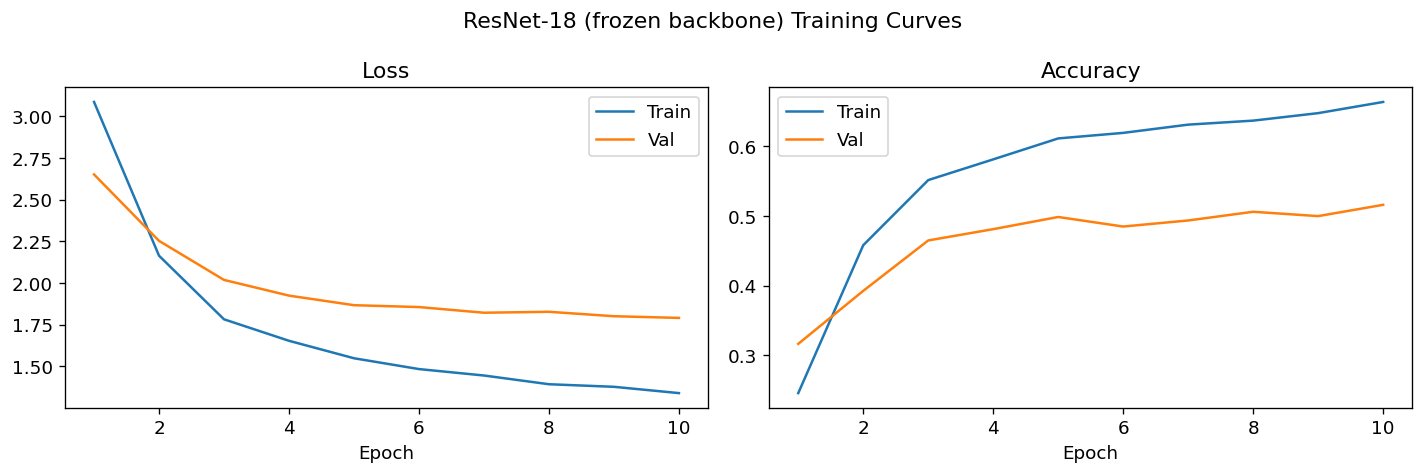


Test Accuracy: 0.506

Per-class report (bottom/top 5 by F1):
                   precision    recall  f1-score  support
Paul Cezanne        0.000000  0.000000  0.000000      5.0
Mikhail Vrubel      0.222222  0.117647  0.153846     17.0
Eugene Delacroix    0.166667  0.333333  0.222222      3.0
Piet Mondrian       0.222222  0.250000  0.235294      8.0
Claude Monet        0.222222  0.285714  0.250000      7.0
Jackson Pollock     0.500000  1.000000  0.666667      2.0
Andy Warhol         0.650000  0.722222  0.684211     18.0
Giotto di Bondone   0.588235  0.833333  0.689655     12.0
William Turner      0.538462  1.000000  0.700000      7.0
Henri Rousseau      0.600000  0.857143  0.705882      7.0


In [9]:
epochs_range = range(1, len(history["val_acc"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.suptitle("ResNet-18 (frozen backbone) Training Curves")
plt.tight_layout()
plt.show()

# --- Test set evaluation ---
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_true.extend(labels.numpy())

print(f"\nTest Accuracy: {np.mean(np.array(all_preds)==np.array(all_true)):.3f}")
print("\nPer-class report (bottom/top 5 by F1):")
report = classification_report(all_true, all_preds,
                                target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).T.iloc[:-3].sort_values("f1-score")
print(pd.concat([report_df.head(5), report_df.tail(5)]).to_string())


In [24]:

def get_model(arch, freeze_backbone=True, unfreeze_layers=None):
    if arch == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    elif arch == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    if freeze_backbone:
        for p in m.parameters():
            p.requires_grad = False

    # 解冻指定层，如 ["layer4"] 或 ["layer3", "layer4"]
    if unfreeze_layers:
        for name, p in m.named_parameters():
            if any(name.startswith(l) for l in unfreeze_layers):
                p.requires_grad = True

    m.fc = nn.Linear(m.fc.in_features, n_classes)
    return m.to(device)



def run_epoch(model, loader, optimizer=None, train=True, desc=""):
    model.train() if train else model.eval()
    total_loss, correct = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, desc=desc, leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(imgs)
            correct    += (out.argmax(1) == labels).sum().item()
            pbar.set_postfix(loss=f"{loss.item():.3f}")
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def train_model(arch, freeze_backbone=True, n_epochs=10, lr=1e-3, unfreeze_layers=None, tag=None):
    if tag is None:
        tag = f"{arch}{'_frozen' if freeze_backbone else '_finetune'}"
    history_path = os.path.join(OUTPUT_DIR, f"{tag}_history.npy")
    model_path   = os.path.join(OUTPUT_DIR, f"{tag}_artist.pt")
    ckpt_path    = os.path.join(OUTPUT_DIR, f"{tag}_checkpoint.pt")

    model = get_model(arch, freeze_backbone, unfreeze_layers)

    if freeze_backbone:
        if unfreeze_layers:
            optimizer = torch.optim.Adam([
                {"params": model.fc.parameters(), "lr": lr},
                {"params": [p for n, p in model.named_parameters()
                            if any(n.startswith(l) for l in unfreeze_layers)], "lr": lr * 0.1},
            ])
        else:
            optimizer = torch.optim.Adam(model.fc.parameters(), lr=lr)

    else:
        optimizer = torch.optim.Adam([
            {"params": model.fc.parameters(), "lr": lr},
            {"params": [p for n, p in model.named_parameters() if "fc" not in n], "lr": lr
  * 0.1},
        ])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"\n[{tag}] Trainable: {trainable:,} / {total:,}")

    # Load if already trained
    if os.path.exists(history_path) and os.path.exists(model_path):
        print(f"[{tag}] Loading saved model...")
        history = np.load(history_path, allow_pickle=True).item()
        model.load_state_dict(torch.load(model_path, map_location=device))
        return model, history

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start_epoch = 1

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        history     = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"[{tag}] Resumed from epoch {ckpt['epoch']}.")

    for epoch in range(start_epoch, n_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer=optimizer, train=True)
        va_loss, va_acc = run_epoch(model, val_loader,   train=False)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        print(f"  Epoch {epoch:02d}/{n_epochs} | "
              f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.3f} acc {va_acc:.3f} | "
              f"{time.time()-t0:.1f}s")

        torch.save({"epoch": epoch, "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(),
                    "history": history}, ckpt_path)

    np.save(history_path, history)
    torch.save(model.state_dict(), model_path)
    if os.path.exists(ckpt_path):
        os.remove(ckpt_path)
    print(f"[{tag}] Saved → {model_path}")
    return model, history


def plot_and_evaluate(model, history, tag):
    # Plot
    epochs_range = range(1, len(history["val_acc"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_range, history["train_loss"], label="Train")
    axes[0].plot(epochs_range, history["val_loss"],   label="Val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].plot(epochs_range, history["train_acc"], label="Train")
    axes[1].plot(epochs_range, history["val_acc"],   label="Val")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.suptitle(f"{tag} Training Curves")
    plt.tight_layout(); plt.show()

    # Evaluate
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            preds = model(imgs.to(device)).argmax(1).cpu()
            all_preds.extend(preds.numpy())
            all_true.extend(labels.numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_true))
    print(f"\n[{tag}] Test Accuracy: {acc:.3f}")
    report = classification_report(all_true, all_preds,
                                    target_names=le.classes_, output_dict=True)
    report_df = pd.DataFrame(report).T.iloc[:-3].sort_values("f1-score")
    print(pd.concat([report_df.head(5), report_df.tail(5)]).to_string())
    return acc

In [22]:
OUTPUT_DIR = os.path.join(os.path.dirname(BASE_DIR), "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)


[resnet18_frozen] Trainable: 25,137 / 11,201,649
[resnet18_frozen] Resumed from epoch 2.


  Epoch 03/10 | train loss 1.798 acc 0.548 | val loss 1.997 acc 0.458 | 83.6s


  Epoch 04/10 | train loss 1.634 acc 0.591 | val loss 1.964 acc 0.480 | 83.0s


  Epoch 05/10 | train loss 1.549 acc 0.611 | val loss 1.893 acc 0.500 | 82.8s


  Epoch 06/10 | train loss 1.511 acc 0.613 | val loss 1.837 acc 0.515 | 83.0s


  Epoch 07/10 | train loss 1.442 acc 0.626 | val loss 1.848 acc 0.512 | 82.1s


  Epoch 08/10 | train loss 1.407 acc 0.632 | val loss 1.804 acc 0.519 | 82.7s


  Epoch 09/10 | train loss 1.379 acc 0.654 | val loss 1.822 acc 0.514 | 83.7s


  Epoch 10/10 | train loss 1.350 acc 0.660 | val loss 1.793 acc 0.506 | 85.6s
[resnet18_frozen] Saved → /content/drive/MyDrive/209b/209b_project/output/resnet18_frozen_artist.pt


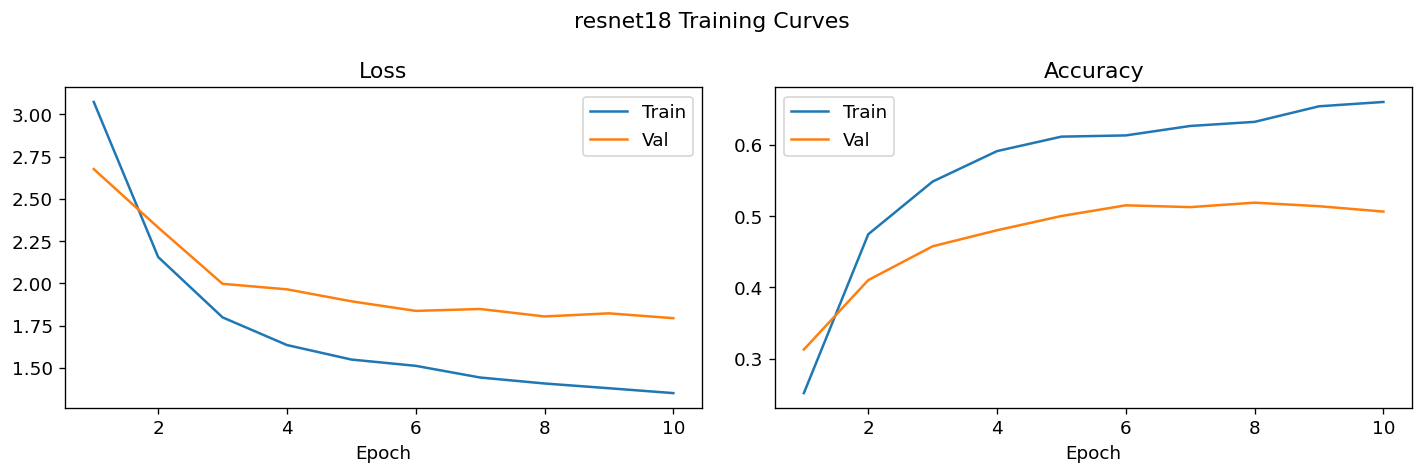


[resnet18] Test Accuracy: 0.521
                   precision    recall  f1-score  support
Paul Cezanne        0.000000  0.000000  0.000000      5.0
Mikhail Vrubel      0.500000  0.058824  0.105263     17.0
Diego Velazquez     0.125000  0.250000  0.166667      4.0
Gustave Courbet     0.200000  0.166667  0.181818      6.0
Eugene Delacroix    0.125000  0.333333  0.181818      3.0
Amedeo Modigliani   0.681818  0.789474  0.731707     19.0
William Turner      0.583333  1.000000  0.736842      7.0
Joan Miro           0.777778  0.700000  0.736842     10.0
Giotto di Bondone   0.769231  0.833333  0.800000     12.0
Jackson Pollock     0.666667  1.000000  0.800000      2.0
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 219MB/s]



[resnet50_frozen] Trainable: 100,401 / 23,608,433


  Epoch 01/10 | train loss 2.660 acc 0.425 | val loss 2.343 acc 0.460 | 96.6s


  Epoch 02/10 | train loss 1.688 acc 0.638 | val loss 1.930 acc 0.529 | 96.5s


...

  Epoch 06/10 | train loss 0.956 acc 0.805 | val loss 1.466 acc 0.627 | 98.9s


  Epoch 07/10 | train loss 0.917 acc 0.810 | val loss 1.417 acc 0.651 | 97.4s


  Epoch 08/10 | train loss 0.887 acc 0.820 | val loss 1.382 acc 0.648 | 97.3s


  Epoch 09/10 | train loss 0.842 acc 0.825 | val loss 1.386 acc 0.645 | 99.4s


  Epoch 10/10 | train loss 0.836 acc 0.823 | val loss 1.388 acc 0.663 | 97.7s
[resnet50_frozen] Saved → /content/drive/MyDrive/209b/209b_project/output/resnet50_frozen_artist.pt


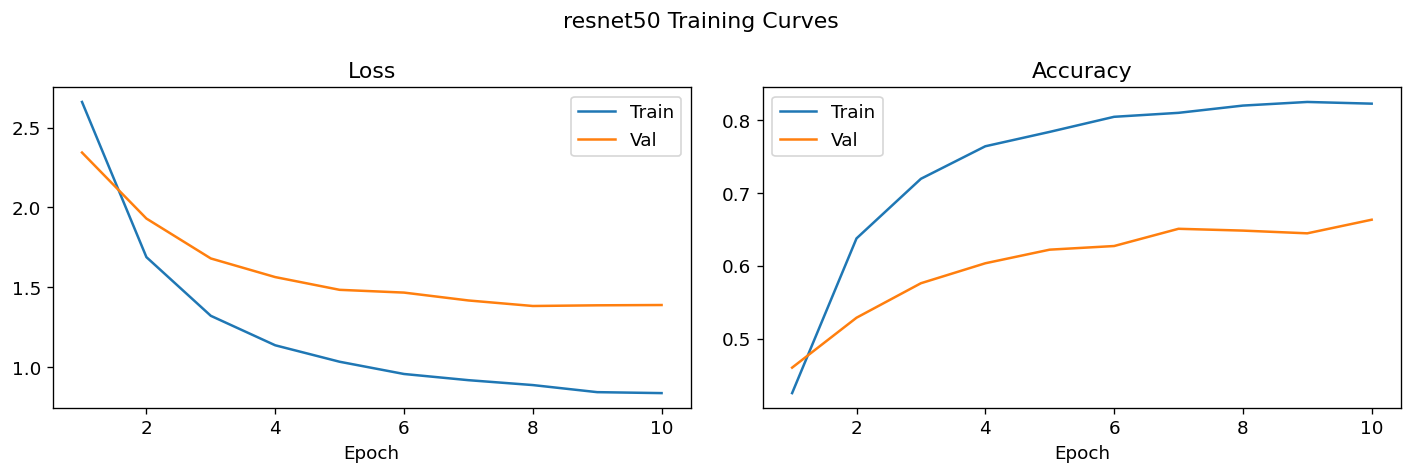


[resnet50] Test Accuracy: 0.620
                    precision    recall  f1-score  support
Paul Cezanne         0.111111  0.200000  0.142857      5.0
Vasiliy Kandinskiy   0.250000  0.222222  0.235294      9.0
Claude Monet         0.285714  0.285714  0.285714      7.0
Diego Velazquez      0.333333  0.250000  0.285714      4.0
Mikhail Vrubel       0.571429  0.235294  0.333333     17.0
Jan van Eyck         0.750000  0.750000  0.750000      8.0
Salvador Dali        0.733333  0.785714  0.758621     14.0
Hieronymus Bosch     0.705882  0.857143  0.774194     14.0
Michelangelo         0.714286  1.000000  0.833333      5.0
Georges Seurat       0.800000  1.000000  0.888889      4.0

=== Final Comparison ===
  resnet18: 0.521
  resnet50: 0.620


In [23]:
criterion = nn.CrossEntropyLoss()   # ← add this
results = {}
for arch in ["resnet18", "resnet50"]:
    model, history = train_model(arch, freeze_backbone=True, n_epochs=10)
    acc = plot_and_evaluate(model, history, tag=arch)
    results[arch] = acc

print("\n=== Final Comparison ===")
for arch, acc in results.items():
    print(f"  {arch}: {acc:.3f}")


[resnet18_unfreeze_l3l4] Trainable: 10,518,577 / 11,201,649
[resnet18_unfreeze_l3l4] Loading saved model...


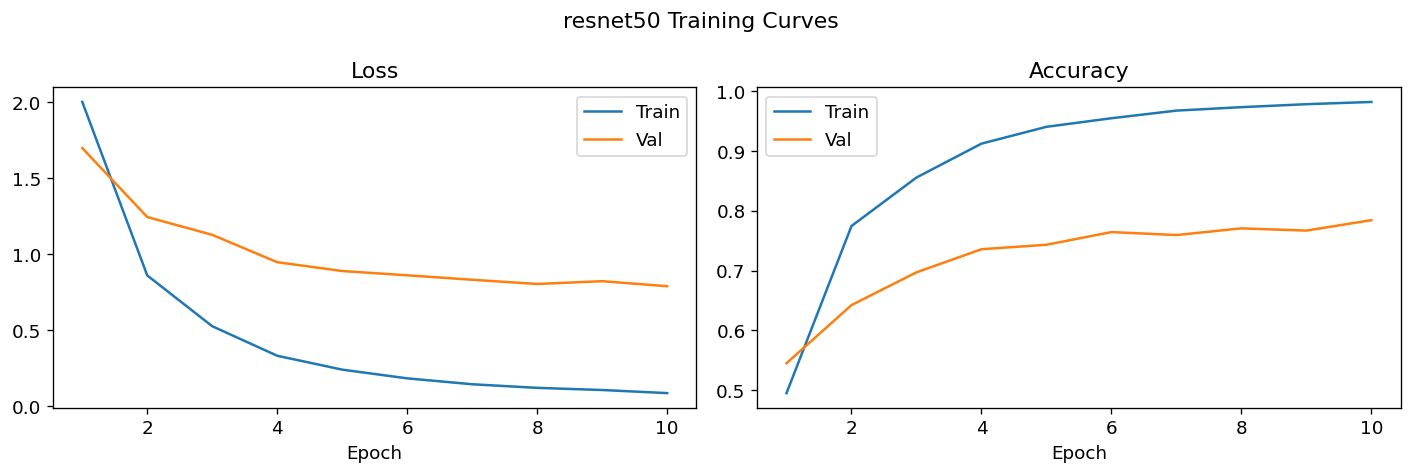


[resnet50] Test Accuracy: 0.772
                  precision    recall  f1-score  support
Eugene Delacroix   0.333333  0.333333  0.333333      3.0
Diego Velazquez    0.500000  0.250000  0.333333      4.0
Gustave Courbet    0.400000  0.333333  0.363636      6.0
Claude Monet       0.428571  0.428571  0.428571      7.0
Paul Cezanne       0.500000  0.400000  0.444444      5.0
Henri Rousseau     1.000000  0.857143  0.923077      7.0
William Turner     0.875000  1.000000  0.933333      7.0
Jan van Eyck       1.000000  0.875000  0.933333      8.0
El Greco           1.000000  0.888889  0.941176      9.0
Diego Rivera       1.000000  1.000000  1.000000      7.0


In [26]:
model, history = train_model("resnet18", freeze_backbone=True,
                              unfreeze_layers=["layer3", "layer4"], n_epochs=10,
                              tag="resnet18_unfreeze_l3l4")
acc = plot_and_evaluate(model, history, tag=arch)

In [27]:
# 全部解冻
train_model("resnet18", freeze_backbone=False, tag="resnet18_finetune")


[resnet18_finetune] Trainable: 11,201,649 / 11,201,649


  Epoch 01/10 | train loss 2.033 acc 0.486 | val loss 1.609 acc 0.561 | 96.4s


  Epoch 02/10 | train loss 0.878 acc 0.762 | val loss 1.282 acc 0.642 | 95.7s


  Epoch 03/10 | train loss 0.543 acc 0.861 | val loss 1.091 acc 0.698 | 97.3s


  Epoch 04/10 | train loss 0.298 acc 0.925 | val loss 0.857 acc 0.772 | 95.0s


...

  Epoch 07/10 | train loss 0.131 acc 0.972 | val loss 0.799 acc 0.792 | 98.0s


  Epoch 08/10 | train loss 0.117 acc 0.975 | val loss 0.781 acc 0.783 | 95.3s


  Epoch 09/10 | train loss 0.101 acc 0.979 | val loss 0.784 acc 0.774 | 95.0s


  Epoch 10/10 | train loss 0.086 acc 0.982 | val loss 0.760 acc 0.789 | 95.3s
[resnet18_finetune] Saved → /content/drive/MyDrive/209b/209b_project/output/resnet18_finetune_artist.pt


(ResNet(
   (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
   (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (relu): ReLU(inplace=True)
   (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
   (layer1): Sequential(
     (0): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
       (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
     (1): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU

---
## 3. Additional Baselines

We compare three more architectures against ResNet-18:

| Model | Architecture | Why useful |
|---|---|---|
| **ViT-B/16** | Vision Transformer | Global attention, very different inductive bias from CNNs |
| **EfficientNet-B0** | Scaled CNN | Strong accuracy-per-parameter on small datasets |
| **CLIP (ViT-B/32)** | Multimodal Transformer | Zero-shot + linear-probe; tests whether art-world language priors help |

All three use the same frozen-backbone / linear-head setup as ResNet-18 for a fair comparison.

In [ ]:
def build_and_train(model_name, get_model_fn, n_epochs=10, lr=1e-3, batch_size=32):
    """Generic train/eval loop with checkpoint save/resume for any frozen-backbone model."""
    model_obj, train_tf_m, val_tf_m = get_model_fn()
    model_obj = model_obj.to(device)

    train_ds_m = ArtDataset(X_train, y_train, train_tf_m)
    val_ds_m   = ArtDataset(X_val,   y_val,   val_tf_m)
    test_ds_m  = ArtDataset(X_test,  y_test,  val_tf_m)

    label_counts_m = np.bincount(y_train)
    w_m = 1.0 / label_counts_m[y_train]
    sampler_m = WeightedRandomSampler(w_m, num_samples=len(w_m), replacement=True)

    tl = DataLoader(train_ds_m, batch_size=batch_size, sampler=sampler_m, num_workers=0)
    vl = DataLoader(val_ds_m,   batch_size=64, shuffle=False, num_workers=0)
    el = DataLoader(test_ds_m,  batch_size=64, shuffle=False, num_workers=0)

    history_path = f"{model_name}_history.npy"
    weights_path = f"{model_name}_artist.pt"
    ckpt_path    = f"{model_name}_checkpoint.pt"

    # ── Already fully trained ──────────────────────────────────────────────
    if os.path.exists(history_path) and os.path.exists(weights_path):
        print(f"[{model_name}] Loading final checkpoint...")
        hist = np.load(history_path, allow_pickle=True).item()
        model_obj.load_state_dict(torch.load(weights_path, map_location=device))
        print(f"[{model_name}] Done. Epochs recorded: {len(hist['val_acc'])}")
        return model_obj, hist, el

    # ── Optimizer / scheduler ──────────────────────────────────────────────
    head_params = [p for p in model_obj.parameters() if p.requires_grad]
    opt  = torch.optim.Adam(head_params, lr=lr)
    sch  = torch.optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.5)
    crit = nn.CrossEntropyLoss()

    hist        = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start_epoch = 1

    # ── Resume from per-epoch checkpoint if training was interrupted ───────
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        model_obj.load_state_dict(ckpt["model"])
        opt.load_state_dict(ckpt["optimizer"])
        sch.load_state_dict(ckpt["scheduler"])
        hist        = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"[{model_name}] Resumed from epoch {ckpt['epoch']}.")

    # ── Training loop ──────────────────────────────────────────────────────
    for epoch in range(start_epoch, n_epochs + 1):
        t0 = time.time()
        for split, loader, is_train in [("train", tl, True), ("val", vl, False)]:
            model_obj.train() if is_train else model_obj.eval()
            total_loss, correct = 0.0, 0
            ctx = torch.enable_grad() if is_train else torch.no_grad()
            with ctx:
                for imgs, labels in loader:
                    imgs, labels = imgs.to(device), labels.to(device)
                    out  = model_obj(imgs)
                    loss = crit(out, labels)
                    if is_train:
                        opt.zero_grad(); loss.backward(); opt.step()
                    total_loss += loss.item() * len(imgs)
                    correct    += (out.argmax(1) == labels).sum().item()
            n = len(loader.dataset)
            hist[f"{split}_loss"].append(total_loss / n)
            hist[f"{split}_acc"].append(correct / n)
        sch.step()
        print(f"  [{model_name}] Epoch {epoch:02d}/{n_epochs} | "
              f"train {hist['train_acc'][-1]:.3f} | val {hist['val_acc'][-1]:.3f} | "
              f"{time.time()-t0:.1f}s")

        # Per-epoch checkpoint (overwrites previous — only keeps latest)
        torch.save({
            "epoch":     epoch,
            "model":     model_obj.state_dict(),
            "optimizer": opt.state_dict(),
            "scheduler": sch.state_dict(),
            "history":   hist,
        }, ckpt_path)

    # ── Save final artifacts; clean up checkpoint ──────────────────────────
    np.save(history_path, hist)
    torch.save(model_obj.state_dict(), weights_path)
    if os.path.exists(ckpt_path):
        os.remove(ckpt_path)
    print(f"  [{model_name}] Saved → {weights_path}, {history_path}")
    return model_obj, hist, el


def evaluate(model_obj, loader):
    model_obj.eval()
    preds, trues = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds.extend(model_obj(imgs.to(device)).argmax(1).cpu().numpy())
            trues.extend(labels.numpy())
    return np.array(preds), np.array(trues)


### 3.1 ViT-B/16

In [ ]:
def get_vit():
    m = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    for p in m.parameters():
        p.requires_grad = False
    m.heads.head = nn.Linear(m.heads.head.in_features, n_classes)

    # ViT expects 224×224; use same ImageNet stats
    tf_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    tf_val = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return m, tf_train, tf_val

print("Training ViT-B/16...")
vit_model, vit_hist, vit_test_loader = build_and_train("vit_b16", get_vit, n_epochs=10)
vit_preds, vit_true = evaluate(vit_model, vit_test_loader)
print(f"ViT-B/16 Test Accuracy: {np.mean(vit_preds == vit_true):.3f}")


Training ViT-B/16...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 242MB/s]


  [vit_b16] Epoch 01/10 | train 0.458 | val 0.456 | 119.9s
  [vit_b16] Epoch 02/10 | train 0.712 | val 0.546 | 119.1s
  [vit_b16] Epoch 03/10 | train 0.787 | val 0.576 | 120.4s
  [vit_b16] Epoch 04/10 | train 0.821 | val 0.599 | 120.2s
  [vit_b16] Epoch 05/10 | train 0.845 | val 0.606 | 120.1s
  [vit_b16] Epoch 06/10 | train 0.868 | val 0.610 | 121.0s
  [vit_b16] Epoch 07/10 | train 0.877 | val 0.628 | 119.6s
  [vit_b16] Epoch 08/10 | train 0.889 | val 0.623 | 119.7s
  [vit_b16] Epoch 09/10 | train 0.898 | val 0.630 | 119.7s
  [vit_b16] Epoch 10/10 | train 0.887 | val 0.637 | 119.4s
  [vit_b16] Saved → vit_b16_artist.pt, vit_b16_history.npy
ViT-B/16 Test Accuracy: 0.648


### 3.2 EfficientNet-B0

In [ ]:
def get_efficientnet():
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    for p in m.parameters():
        p.requires_grad = False
    in_features = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(in_features, n_classes)

    tf_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    tf_val = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return m, tf_train, tf_val

print("Training EfficientNet-B0...")
eff_model, eff_hist, eff_test_loader = build_and_train("efficientnet_b0", get_efficientnet, n_epochs=10)
eff_preds, eff_true = evaluate(eff_model, eff_test_loader)
print(f"EfficientNet-B0 Test Accuracy: {np.mean(eff_preds == eff_true):.3f}")


Training EfficientNet-B0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 196MB/s]


  [efficientnet_b0] Epoch 01/10 | train 0.394 | val 0.420 | 80.2s
  [efficientnet_b0] Epoch 02/10 | train 0.581 | val 0.478 | 79.7s
  [efficientnet_b0] Epoch 03/10 | train 0.637 | val 0.512 | 80.0s
  [efficientnet_b0] Epoch 04/10 | train 0.652 | val 0.526 | 79.7s
  [efficientnet_b0] Epoch 05/10 | train 0.675 | val 0.521 | 78.6s
  [efficientnet_b0] Epoch 06/10 | train 0.686 | val 0.530 | 78.8s
  [efficientnet_b0] Epoch 07/10 | train 0.689 | val 0.529 | 78.2s
  [efficientnet_b0] Epoch 08/10 | train 0.706 | val 0.536 | 78.7s
  [efficientnet_b0] Epoch 09/10 | train 0.717 | val 0.550 | 78.7s
  [efficientnet_b0] Epoch 10/10 | train 0.724 | val 0.544 | 78.1s
  [efficientnet_b0] Saved → efficientnet_b0_artist.pt, efficientnet_b0_history.npy
EfficientNet-B0 Test Accuracy: 0.560


### 3.3 CLIP ViT-B/32 — Zero-shot + Linear Probe

CLIP was trained on image-text pairs from the web, so it already has some notion of art styles.  
We test two settings:
- **Zero-shot**: prompt each class name directly (`"a painting by {artist}"`)
- **Linear probe**: freeze CLIP's image encoder, train a single linear head (same protocol as above)

In [ ]:
try:
    import clip
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/openai/CLIP.git", "-q"])
    import clip

clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

# ---- Zero-shot evaluation ----
artist_names = list(le.classes_)
text_prompts = clip.tokenize([f"a painting by {name}" for name in artist_names]).to(device)

with torch.no_grad():
    text_features = clip_model.encode_text(text_prompts)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

# Build test dataset with CLIP's own preprocessing (no augmentation)
clip_test_ds = ArtDataset(X_test, y_test,
                           transforms.Compose([clip_preprocess]))
clip_test_loader = DataLoader(clip_test_ds, batch_size=64, shuffle=False, num_workers=0)

zs_preds, zs_true = [], []
with torch.no_grad():
    for imgs, labels in clip_test_loader:
        img_features = clip_model.encode_image(imgs.to(device))
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)
        logits = (img_features @ text_features.T)
        zs_preds.extend(logits.argmax(1).cpu().numpy())
        zs_true.extend(labels.numpy())

clip_zs_acc = np.mean(np.array(zs_preds) == np.array(zs_true))
print(f"CLIP Zero-shot Accuracy: {clip_zs_acc:.3f}")


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 113MiB/s]


CLIP Zero-shot Accuracy: 0.638


In [ ]:
# ---- CLIP Linear Probe ----
class CLIPLinearProbe(nn.Module):
    def __init__(self, clip_encoder, n_cls):
        super().__init__()
        self.encoder = clip_encoder
        self.head = nn.Linear(512, n_cls)  # ViT-B/32 image embed dim = 512

    def forward(self, x):
        with torch.no_grad():
            feats = self.encoder.encode_image(x).float()
            feats = feats / feats.norm(dim=-1, keepdim=True)
        return self.head(feats)

def get_clip_probe():
    probe = CLIPLinearProbe(clip_model, n_classes)
    for p in probe.encoder.parameters():
        p.requires_grad = False

    clip_train_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.48145466, 0.4578275, 0.40821073),
                             (0.26862954, 0.26130258, 0.27577711)),
    ])
    clip_val_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.48145466, 0.4578275, 0.40821073),
                             (0.26862954, 0.26130258, 0.27577711)),
    ])
    return probe, clip_train_tf, clip_val_tf

print("Training CLIP linear probe...")
clip_probe, clip_hist, clip_probe_loader = build_and_train(
    "clip_linear_probe", get_clip_probe, n_epochs=10, lr=1e-3)
clip_lp_preds, clip_lp_true = evaluate(clip_probe, clip_probe_loader)
print(f"CLIP Linear-Probe Accuracy: {np.mean(clip_lp_preds == clip_lp_true):.3f}")


Training CLIP linear probe...
  [clip_linear_probe] Epoch 01/10 | train 0.294 | val 0.468 | 63.9s
  [clip_linear_probe] Epoch 02/10 | train 0.539 | val 0.483 | 63.6s
  [clip_linear_probe] Epoch 03/10 | train 0.629 | val 0.502 | 63.3s
  [clip_linear_probe] Epoch 04/10 | train 0.638 | val 0.537 | 63.3s
  [clip_linear_probe] Epoch 05/10 | train 0.646 | val 0.522 | 62.4s
  [clip_linear_probe] Epoch 06/10 | train 0.652 | val 0.551 | 62.4s
  [clip_linear_probe] Epoch 07/10 | train 0.664 | val 0.555 | 62.6s
  [clip_linear_probe] Epoch 08/10 | train 0.670 | val 0.565 | 63.0s
  [clip_linear_probe] Epoch 09/10 | train 0.667 | val 0.565 | 63.4s
  [clip_linear_probe] Epoch 10/10 | train 0.683 | val 0.567 | 64.2s
  [clip_linear_probe] Saved → clip_linear_probe_artist.pt, clip_linear_probe_history.npy
CLIP Linear-Probe Accuracy: 0.563


### 3.4 Baseline Comparison Summary

Model                  Test Acc
----------------------------------------
ViT-B/16                  0.648
CLIP Zero-shot            0.638
CLIP Linear Probe         0.563
EfficientNet-B0           0.560
ResNet-18                 0.538


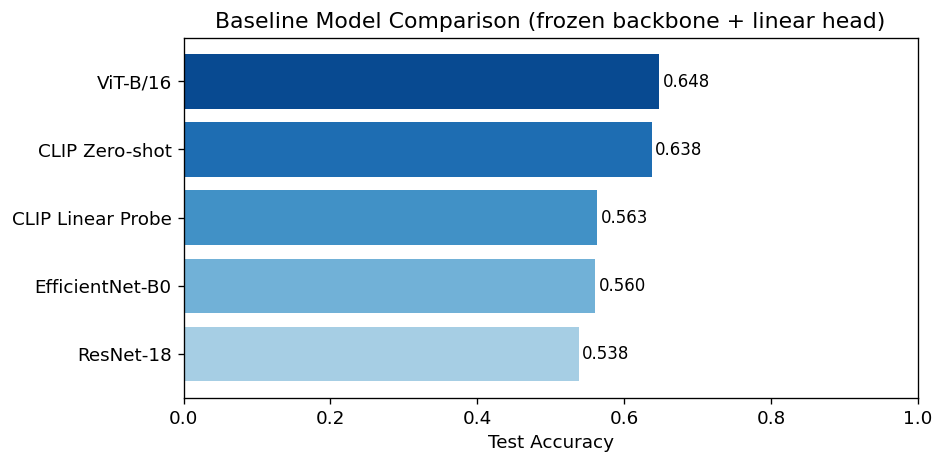

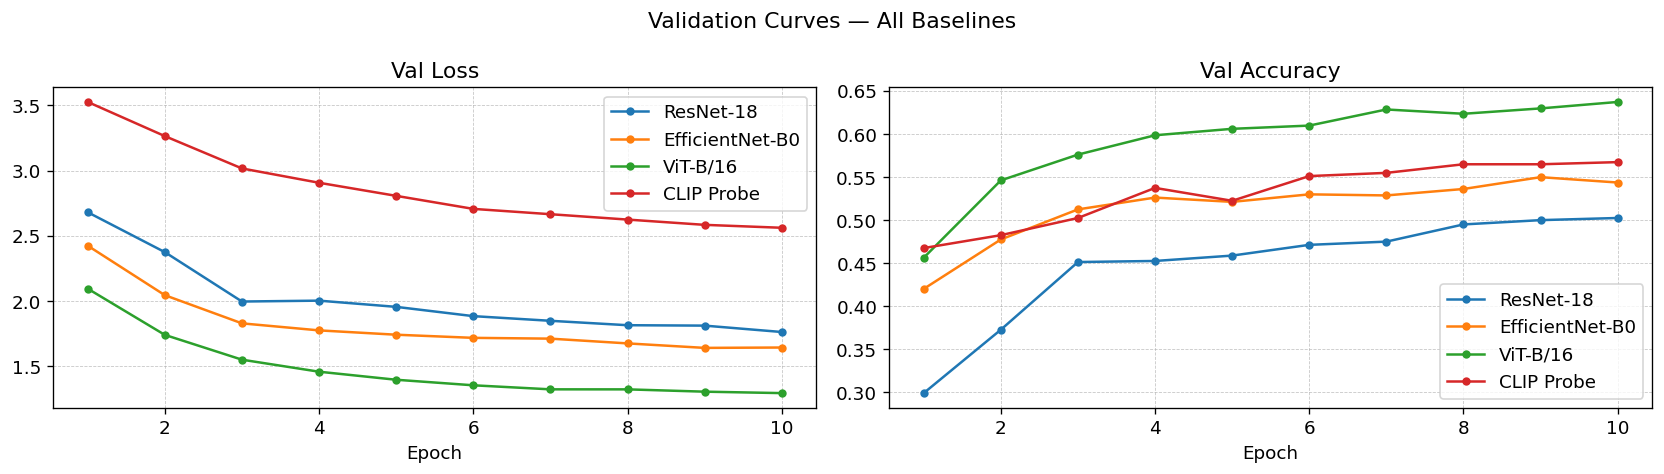

In [ ]:
resnet_preds = np.array(all_preds)
resnet_true  = np.array(all_true)

results = {
    "ResNet-18":          np.mean(resnet_preds == resnet_true),
    "EfficientNet-B0":    np.mean(eff_preds    == eff_true),
    "ViT-B/16":           np.mean(vit_preds    == vit_true),
    "CLIP Zero-shot":     clip_zs_acc,
    "CLIP Linear Probe":  np.mean(clip_lp_preds == clip_lp_true),
}

print("=" * 40)
print(f"{'Model':<22} {'Test Acc':>8}")
print("-" * 40)
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name:<22} {acc:>8.3f}")
print("=" * 40)

fig, ax = plt.subplots(figsize=(8, 4))
names, accs = zip(*sorted(results.items(), key=lambda x: x[1]))
n = len(names)
colors = [plt.cm.Blues(0.35 + 0.55 * i / (n - 1)) for i in range(n)]
bars = ax.barh(names, accs, color=colors)
ax.set_xlabel("Test Accuracy")
ax.set_title("Baseline Model Comparison (frozen backbone + linear head)")
ax.set_xlim(0, 1)
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{acc:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

# Training curves side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, hist in [("ResNet-18", history), ("EfficientNet-B0", eff_hist),
                     ("ViT-B/16", vit_hist), ("CLIP Probe", clip_hist)]:
    epochs = range(1, len(hist["val_acc"]) + 1)
    axes[0].plot(epochs, hist["val_loss"], label=label, marker="o", markersize=4)
    axes[1].plot(epochs, hist["val_acc"],  label=label, marker="o", markersize=4)

for ax in axes:
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

axes[0].set_title("Val Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Val Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.suptitle("Validation Curves — All Baselines")
plt.tight_layout()
plt.show()


---
## 4. Failure Analysis

We use the **best-performing model** (by test accuracy) and dig into where it goes wrong.

Four views:
1. **Confusion heatmap** — which artist pairs are most confused?
2. **Per-class accuracy bar chart** — who is hardest to classify?
3. **Sample failure gallery** — actual images the model got wrong (true vs. predicted label + confidence)
4. **Confusion pair drill-down** — images from the most confused pair

In [ ]:
# Pick best model by test accuracy
best_name, best_acc = max(results.items(), key=lambda x: x[1])
print(f"Best model: {best_name}  (acc={best_acc:.3f})")

# Map model name -> (preds, true, test_paths)
model_preds_map = {
    "ResNet-18":         (resnet_preds,   resnet_true,   X_test),
    "EfficientNet-B0":   (eff_preds,      eff_true,      X_test),
    "ViT-B/16":          (vit_preds,      vit_true,      X_test),
    "CLIP Linear Probe": (clip_lp_preds,  clip_lp_true,  X_test),
}

best_preds, best_true, best_paths = model_preds_map[best_name]

# Failure mask
fail_mask = best_preds != best_true
fail_preds = best_preds[fail_mask]
fail_true  = best_true[fail_mask]
fail_paths = [best_paths[i] for i, f in enumerate(fail_mask) if f]
print(f"Total failures: {fail_mask.sum()} / {len(best_true)} "
      f"({fail_mask.mean()*100:.1f}%)")


Best model: ViT-B/16  (acc=0.648)
Total failures: 283 / 803 (35.2%)


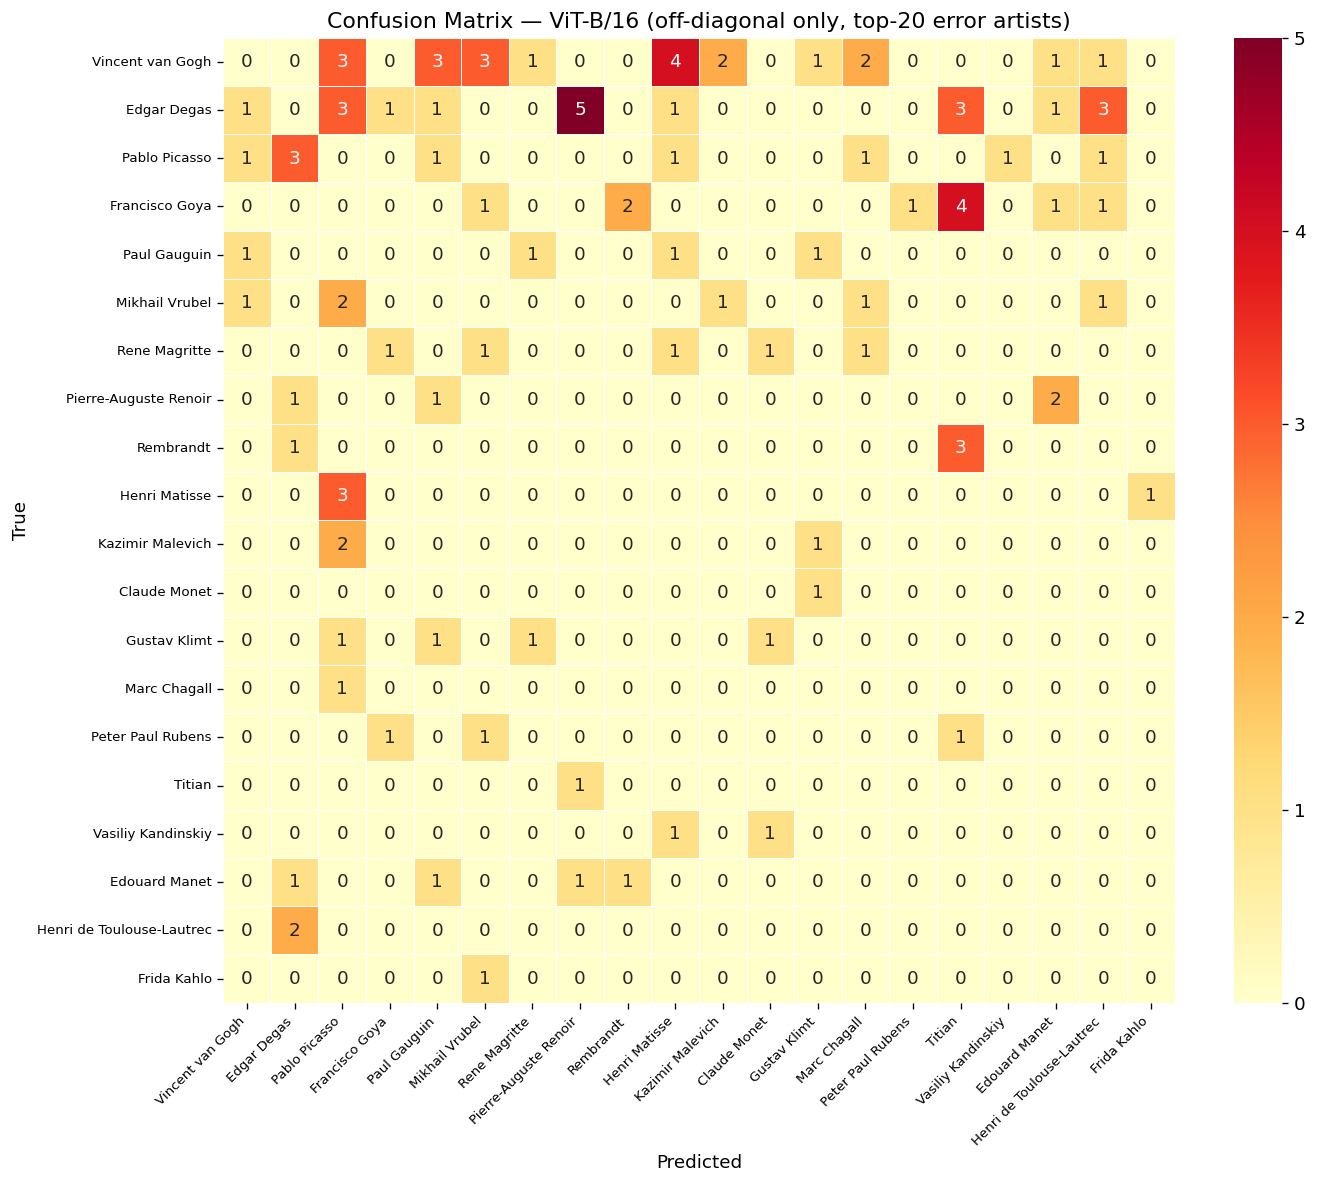

In [ ]:
from sklearn.metrics import confusion_matrix

# ---- 1. Confusion heatmap (top-N most confused classes) ----
cm = confusion_matrix(best_true, best_preds, labels=range(n_classes))
np.fill_diagonal(cm, 0)  # zero out correct predictions to focus on errors

# Show only the 20 artists with the most errors
error_counts = cm.sum(axis=1)
top_idx = np.argsort(error_counts)[-20:][::-1]
cm_sub = cm[np.ix_(top_idx, top_idx)]
labels_sub = le.classes_[top_idx]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_sub, xticklabels=labels_sub, yticklabels=labels_sub,
            annot=True, fmt="d", cmap="YlOrRd", ax=ax, linewidths=0.3)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {best_name} (off-diagonal only, top-20 error artists)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


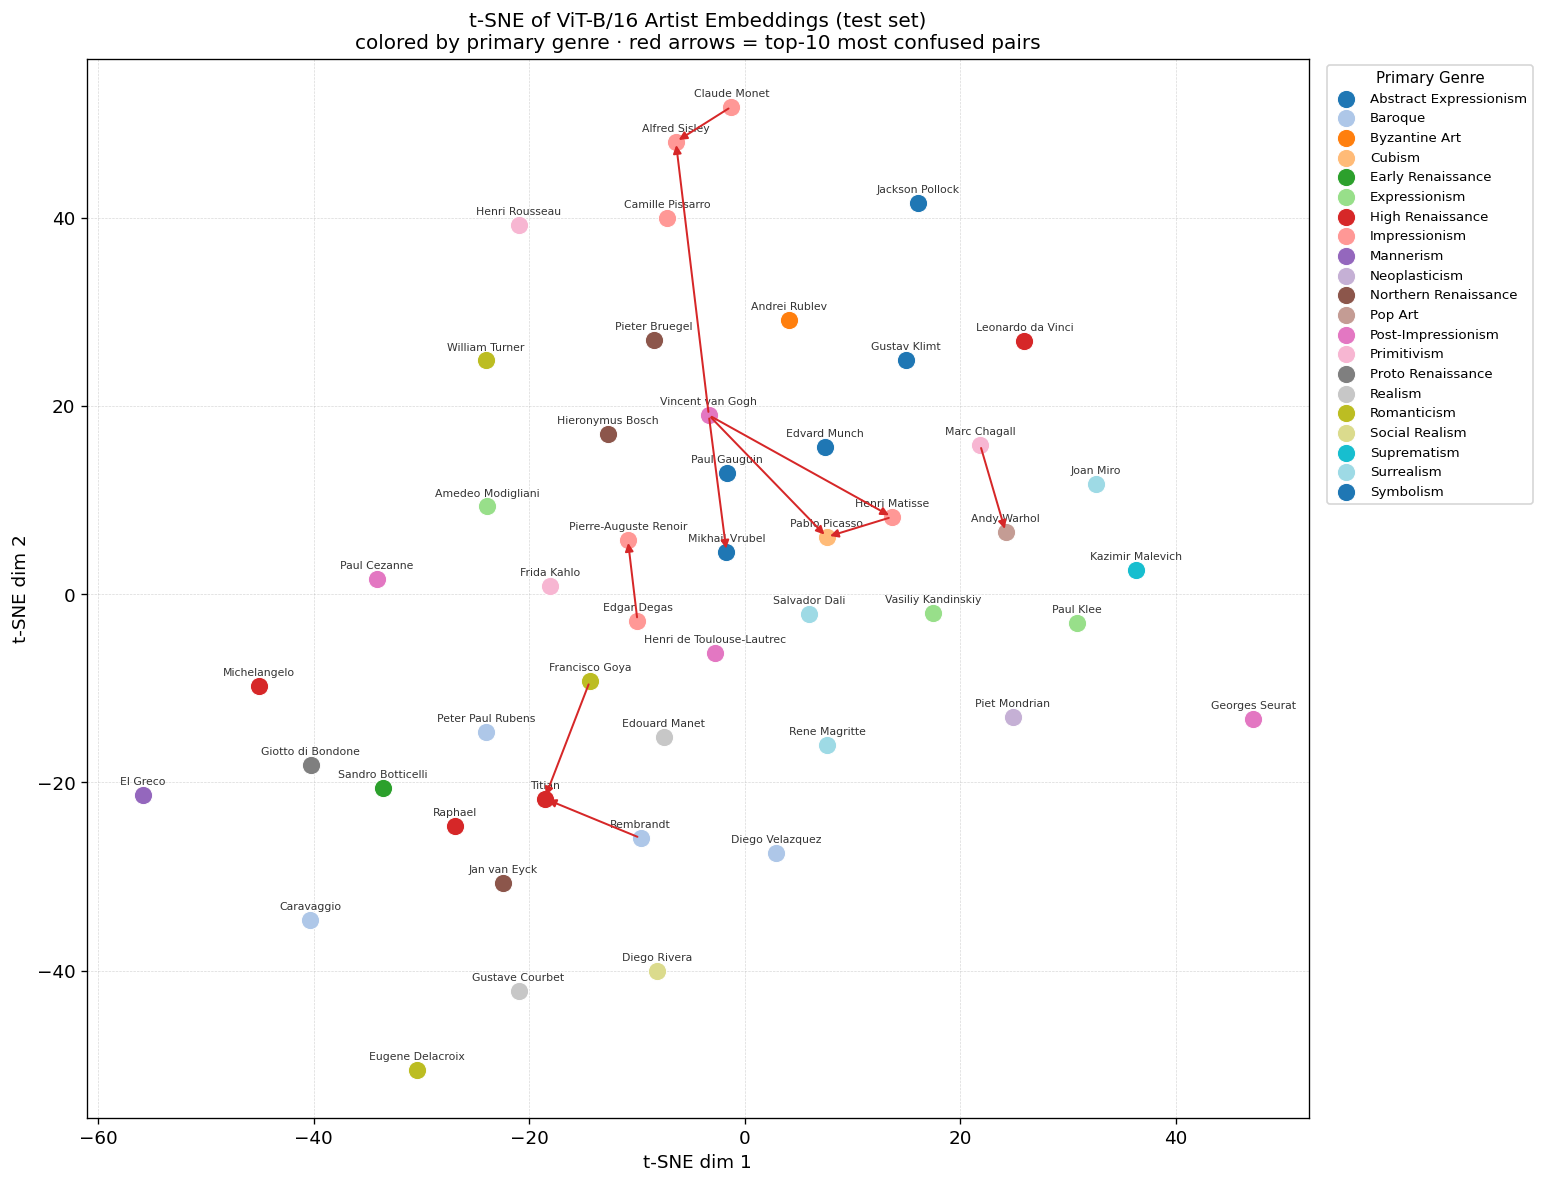

In [ ]:
from sklearn.manifold import TSNE

# ---- Extract per-image ViT features from test set ----
vit_model.eval()
all_feats, all_feat_labels = [], []

feat_store = []
def feat_hook(module, input, output):
    feat_store.append(output[:, 0, :].cpu())  # CLS token

hook = vit_model.encoder.register_forward_hook(feat_hook)

with torch.no_grad():
    for imgs, labels in DataLoader(
            ArtDataset(X_test, y_test, val_tf), batch_size=64, shuffle=False, num_workers=0):
        feat_store.clear()
        _ = vit_model(imgs.to(device))
        all_feats.append(feat_store[0])
        all_feat_labels.extend(labels.numpy())

hook.remove()

all_feats = torch.cat(all_feats, dim=0).numpy()
all_feat_labels = np.array(all_feat_labels)

# Average per artist -> one point per artist
artist_feats = []
artist_names_order = []
for idx, cls in enumerate(le.classes_):
    mask = all_feat_labels == idx
    if mask.sum() == 0:
        continue
    artist_feats.append(all_feats[mask].mean(axis=0))
    artist_names_order.append(cls)

artist_feats = np.stack(artist_feats)

# t-SNE to 2D
tsne = TSNE(n_components=2, perplexity=min(15, len(artist_names_order) - 1),
            random_state=42, n_iter=1000)
coords = tsne.fit_transform(artist_feats)

# ---- Color by primary genre ----
primary_genre = [class_to_genres[a][0] for a in artist_names_order]
unique_genres = sorted(set(primary_genre))
tab20_colors = plt.cm.tab20.colors
palette = {g: tab20_colors[i % len(tab20_colors)] for i, g in enumerate(unique_genres)}

# Most-confused pairs (top 10) for arrow overlay
cm_arr = confusion_matrix(vit_true, vit_preds, labels=range(n_classes))
np.fill_diagonal(cm_arr, 0)
flat = cm_arr.flatten()
top_pairs_idx = np.argsort(flat)[-10:][::-1]
top_pairs = [(i // n_classes, i % n_classes) for i in top_pairs_idx if flat[i] > 0]

artist_idx_map = {cls: i for i, cls in enumerate(artist_names_order)}

fig, ax = plt.subplots(figsize=(13, 10))

for g in unique_genres:
    idxs = [i for i, pg in enumerate(primary_genre) if pg == g]
    ax.scatter(coords[idxs, 0], coords[idxs, 1],
               color=palette[g], label=g, s=120, edgecolors="white", linewidths=0.6, zorder=3)

for i, name in enumerate(artist_names_order):
    ax.annotate(name, (coords[i, 0], coords[i, 1]),
                fontsize=6.5, ha="center", va="bottom",
                xytext=(0, 5), textcoords="offset points", color="#333333")

for t_idx, p_idx in top_pairs:
    tc, pc = le.classes_[t_idx], le.classes_[p_idx]
    if tc not in artist_idx_map or pc not in artist_idx_map:
        continue
    ti, pi = artist_idx_map[tc], artist_idx_map[pc]
    ax.annotate("", xy=coords[pi], xytext=coords[ti],
                arrowprops=dict(arrowstyle="-|>", color="#d62728",
                                lw=1.2, mutation_scale=10))

ax.legend(title="Primary Genre", bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=8, title_fontsize=9, framealpha=0.8)
ax.set_title(f"t-SNE of ViT-B/16 Artist Embeddings (test set)\n"
             "colored by primary genre · red arrows = top-10 most confused pairs",
             fontsize=12)
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.show()


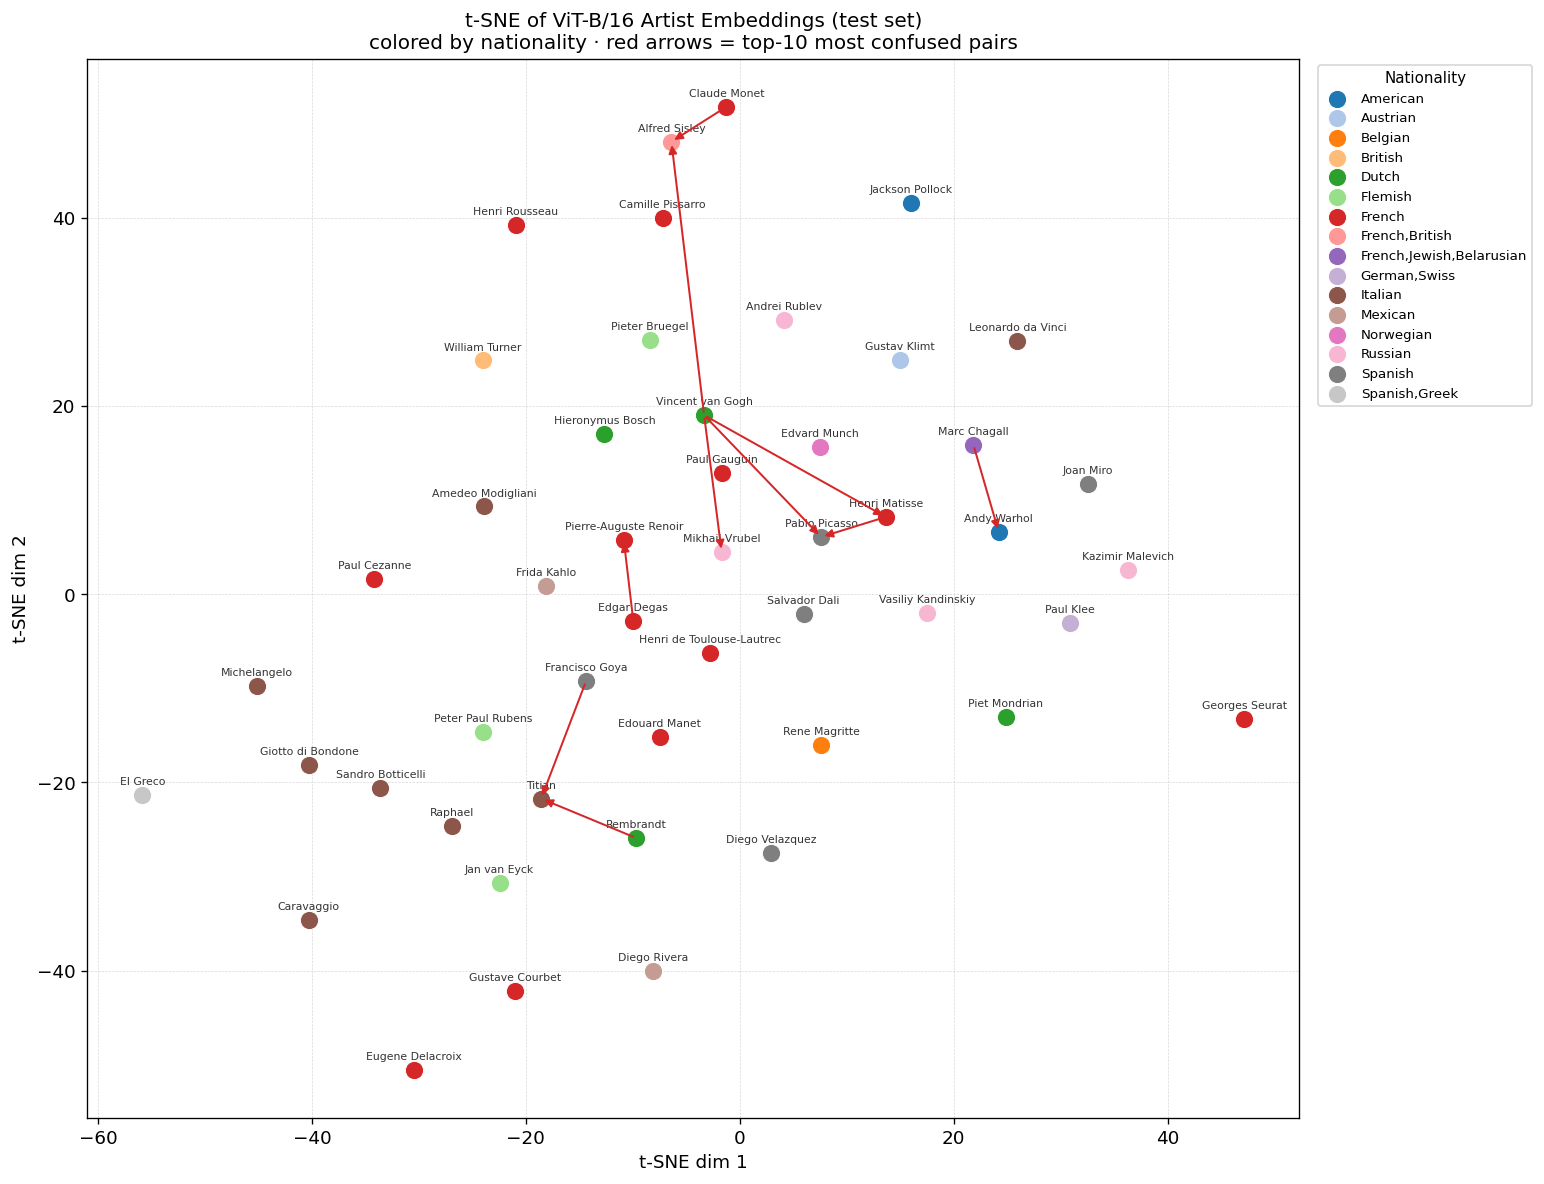

In [ ]:
# ---- t-SNE colored by nationality (reuse coords from genre plot) ----
artist_meta_nat = df.set_index("name")[["nationality"]].copy()

class_to_nationality = {}
for cls in le.classes_:
    if cls in artist_meta_nat.index:
        nat = artist_meta_nat.loc[cls, "nationality"]
        class_to_nationality[cls] = nat.strip() if pd.notna(nat) else "Unknown"
    else:
        class_to_nationality[cls] = "Unknown"

primary_nat = [class_to_nationality[a] for a in artist_names_order]
unique_nats = sorted(set(primary_nat))
palette_nat = {n: tab20_colors[i % len(tab20_colors)] for i, n in enumerate(unique_nats)}

fig, ax = plt.subplots(figsize=(13, 10))

for nat in unique_nats:
    idxs = [i for i, n in enumerate(primary_nat) if n == nat]
    ax.scatter(coords[idxs, 0], coords[idxs, 1],
               color=palette_nat[nat], label=nat, s=120,
               edgecolors="white", linewidths=0.6, zorder=3)

for i, name in enumerate(artist_names_order):
    ax.annotate(name, (coords[i, 0], coords[i, 1]),
                fontsize=6.5, ha="center", va="bottom",
                xytext=(0, 5), textcoords="offset points", color="#333333")

for t_idx, p_idx in top_pairs:
    tc, pc = le.classes_[t_idx], le.classes_[p_idx]
    if tc not in artist_idx_map or pc not in artist_idx_map:
        continue
    ti, pi = artist_idx_map[tc], artist_idx_map[pc]
    ax.annotate("", xy=coords[pi], xytext=coords[ti],
                arrowprops=dict(arrowstyle="-|>", color="#d62728",
                                lw=1.2, mutation_scale=10))

ax.legend(title="Nationality", bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=8, title_fontsize=9, framealpha=0.8)
ax.set_title(f"t-SNE of ViT-B/16 Artist Embeddings (test set)\n"
             "colored by nationality · red arrows = top-10 most confused pairs",
             fontsize=12)
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.show()


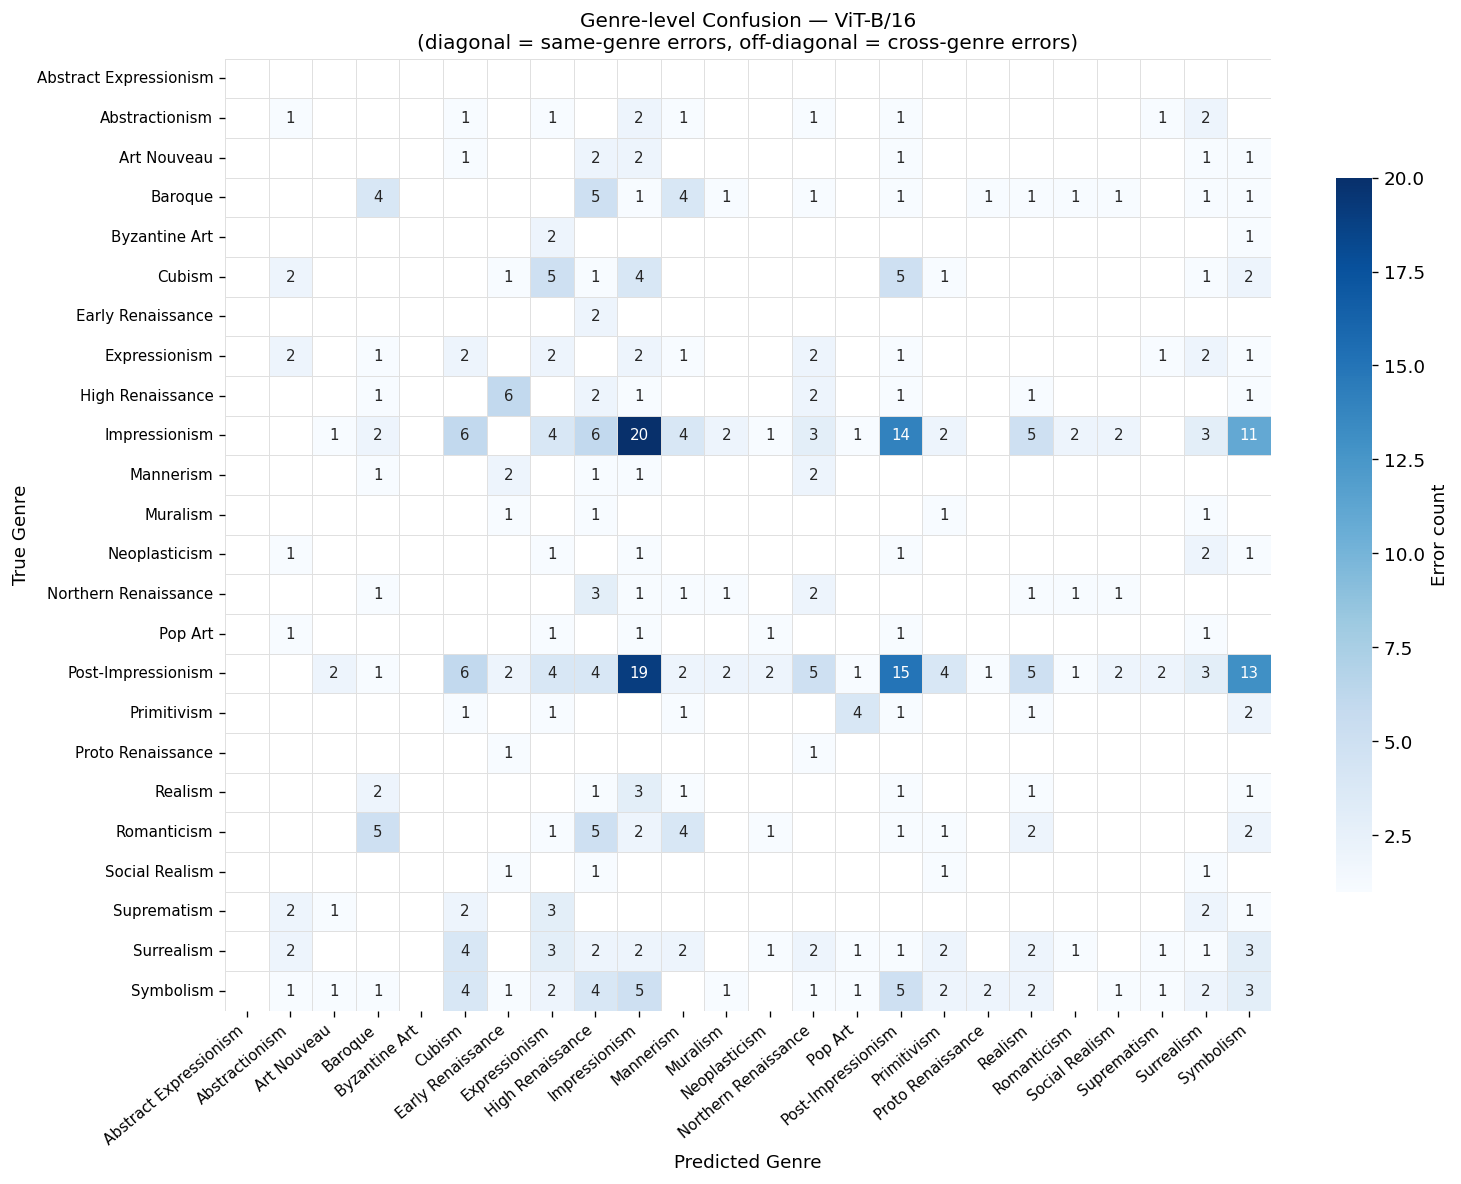

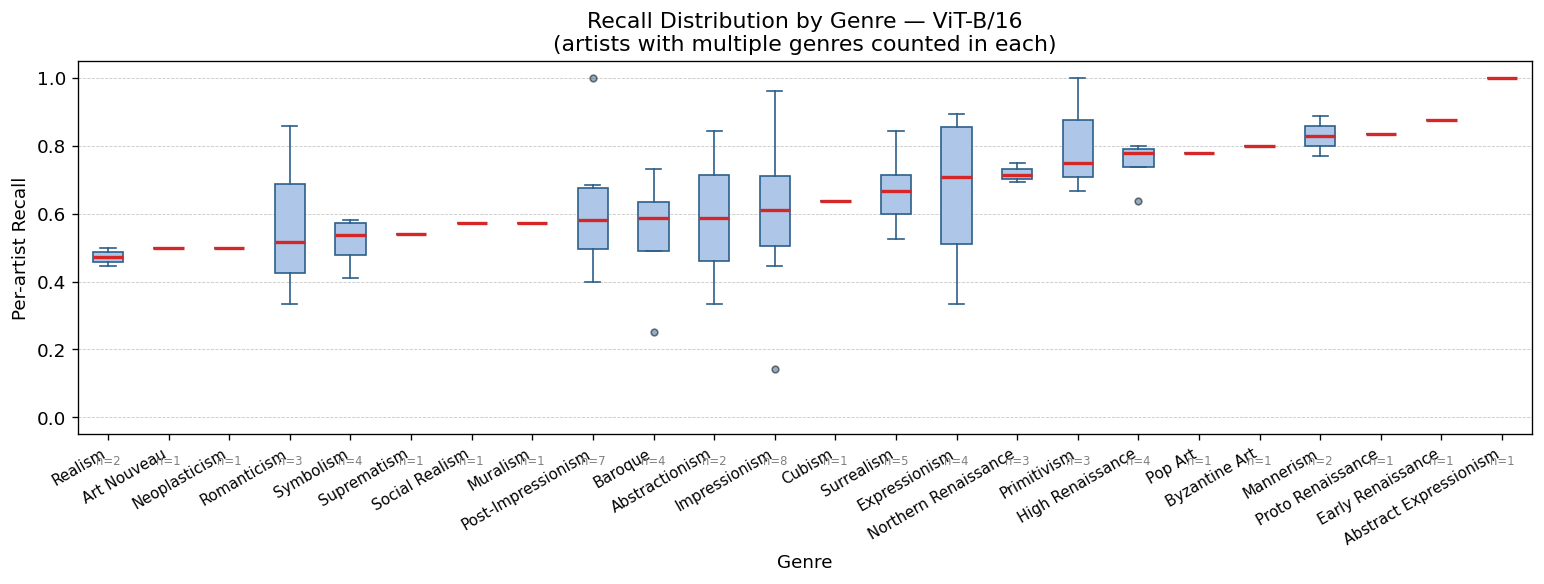

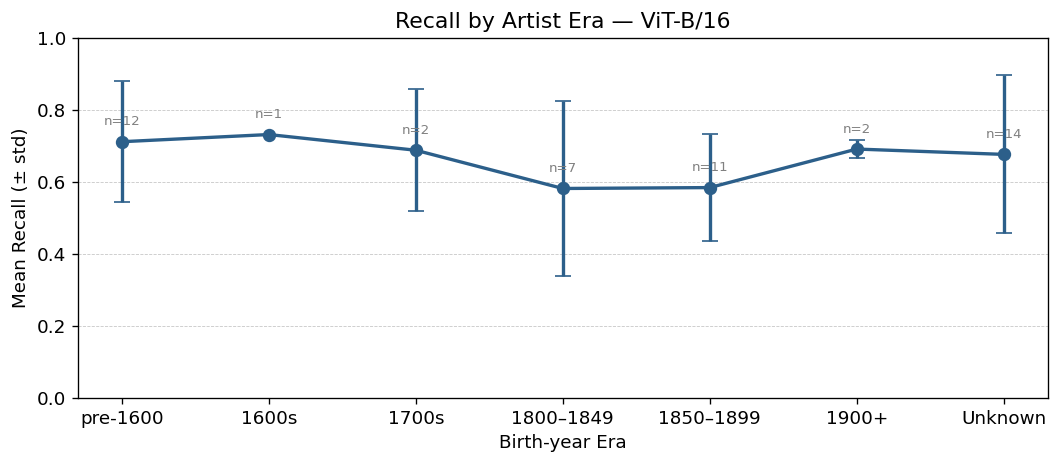

In [ ]:
# Build artist metadata lookup keyed by display name
artist_meta = df.set_index("name")[["genre", "birth_year", "death_year"]].copy()

# Split multi-genre artists (e.g. "Impressionism, Post-Impressionism") into a list
artist_meta["genres_list"] = artist_meta["genre"].fillna("Unknown").apply(
    lambda x: [g.strip() for g in x.split(",")]
)

def era_label(birth_year):
    if pd.isna(birth_year):
        return "Unknown"
    y = int(birth_year)
    if y < 1600: return "pre-1600"
    if y < 1700: return "1600s"
    if y < 1800: return "1700s"
    if y < 1850: return "1800–1849"
    if y < 1900: return "1850–1899"
    return "1900+"

class_to_genres = {}  # cls -> list of genres
class_to_era    = {}
for cls in le.classes_:
    if cls in artist_meta.index:
        row = artist_meta.loc[cls]
        class_to_genres[cls] = row["genres_list"]
        class_to_era[cls]    = era_label(row["birth_year"])
    else:
        class_to_genres[cls] = ["Unknown"]
        class_to_era[cls]    = "Unknown"

# ---- Plot 1: Genre confusion heatmap (multi-genre aware) ----
all_genres = sorted({g for gs in class_to_genres.values() for g in gs})
g2i = {g: i for i, g in enumerate(all_genres)}
n_g = len(all_genres)
genre_cm = np.zeros((n_g, n_g), dtype=float)

for t, p in zip(best_true, best_preds):
    if t == p:
        continue
    for tg in class_to_genres[le.classes_[t]]:
        for pg in class_to_genres[le.classes_[p]]:
            genre_cm[g2i[tg], g2i[pg]] += 1

genre_cm_df = pd.DataFrame(genre_cm, index=all_genres, columns=all_genres)

fig, ax = plt.subplots(figsize=(13, 10))
mask = genre_cm_df == 0  # hide empty cells
sns.heatmap(genre_cm_df, mask=mask,
            annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.5, linecolor="#e0e0e0",
            annot_kws={"size": 9},
            cbar_kws={"shrink": 0.75, "label": "Error count"},
            ax=ax)
ax.set_xlabel("Predicted Genre", fontsize=11)
ax.set_ylabel("True Genre", fontsize=11)
ax.set_title(f"Genre-level Confusion — {best_name}\n"
             "(diagonal = same-genre errors, off-diagonal = cross-genre errors)",
             fontsize=12)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# ---- Plot 2: Recall distribution by genre (multi-genre: artist counted in each genre) ----
recall_by_genre = {}
for cls in le.classes_:
    rec = report_best[cls]["recall"]
    for g in class_to_genres[cls]:
        recall_by_genre.setdefault(g, []).append(rec)

genre_order = sorted(recall_by_genre, key=lambda g: np.median(recall_by_genre[g]))
fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot([recall_by_genre[g] for g in genre_order],
           labels=genre_order, patch_artist=True,
           boxprops=dict(facecolor="#AEC6E8", color="#2c5f8a"),
           medianprops=dict(color="#d62728", linewidth=2),
           whiskerprops=dict(color="#2c5f8a"),
           capprops=dict(color="#2c5f8a"),
           flierprops=dict(marker="o", markerfacecolor="#2c5f8a", markersize=4, alpha=0.5))
for i, g in enumerate(genre_order):
    n = len(recall_by_genre[g])
    ax.text(i + 1, -0.08, f"n={n}", ha="center", fontsize=7, color="gray",
            transform=ax.get_xaxis_transform())
ax.set_ylabel("Per-artist Recall")
ax.set_xlabel("Genre")
ax.set_title(f"Recall Distribution by Genre — {best_name}\n(artists with multiple genres counted in each)")
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
ax.set_ylim(-0.05, 1.05)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

# ---- Plot 3: Recall by birth-year era ----
recall_by_era = {}
for cls in le.classes_:
    e   = class_to_era[cls]
    rec = report_best[cls]["recall"]
    recall_by_era.setdefault(e, []).append(rec)

era_order = ["pre-1600", "1600s", "1700s", "1800–1849", "1850–1899", "1900+", "Unknown"]
era_order = [e for e in era_order if e in recall_by_era]

means  = [np.mean(recall_by_era[e]) for e in era_order]
stds   = [np.std(recall_by_era[e])  for e in era_order]
counts = [len(recall_by_era[e])     for e in era_order]

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(era_order, means, yerr=stds, fmt="o-", color="#2c5f8a",
            capsize=5, linewidth=2, markersize=7)
for i, (e, m, c) in enumerate(zip(era_order, means, counts)):
    ax.annotate(f"n={c}", (i, m), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=8, color="gray")
ax.set_ylabel("Mean Recall (± std)")
ax.set_xlabel("Birth-year Era")
ax.set_title(f"Recall by Artist Era — {best_name}")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


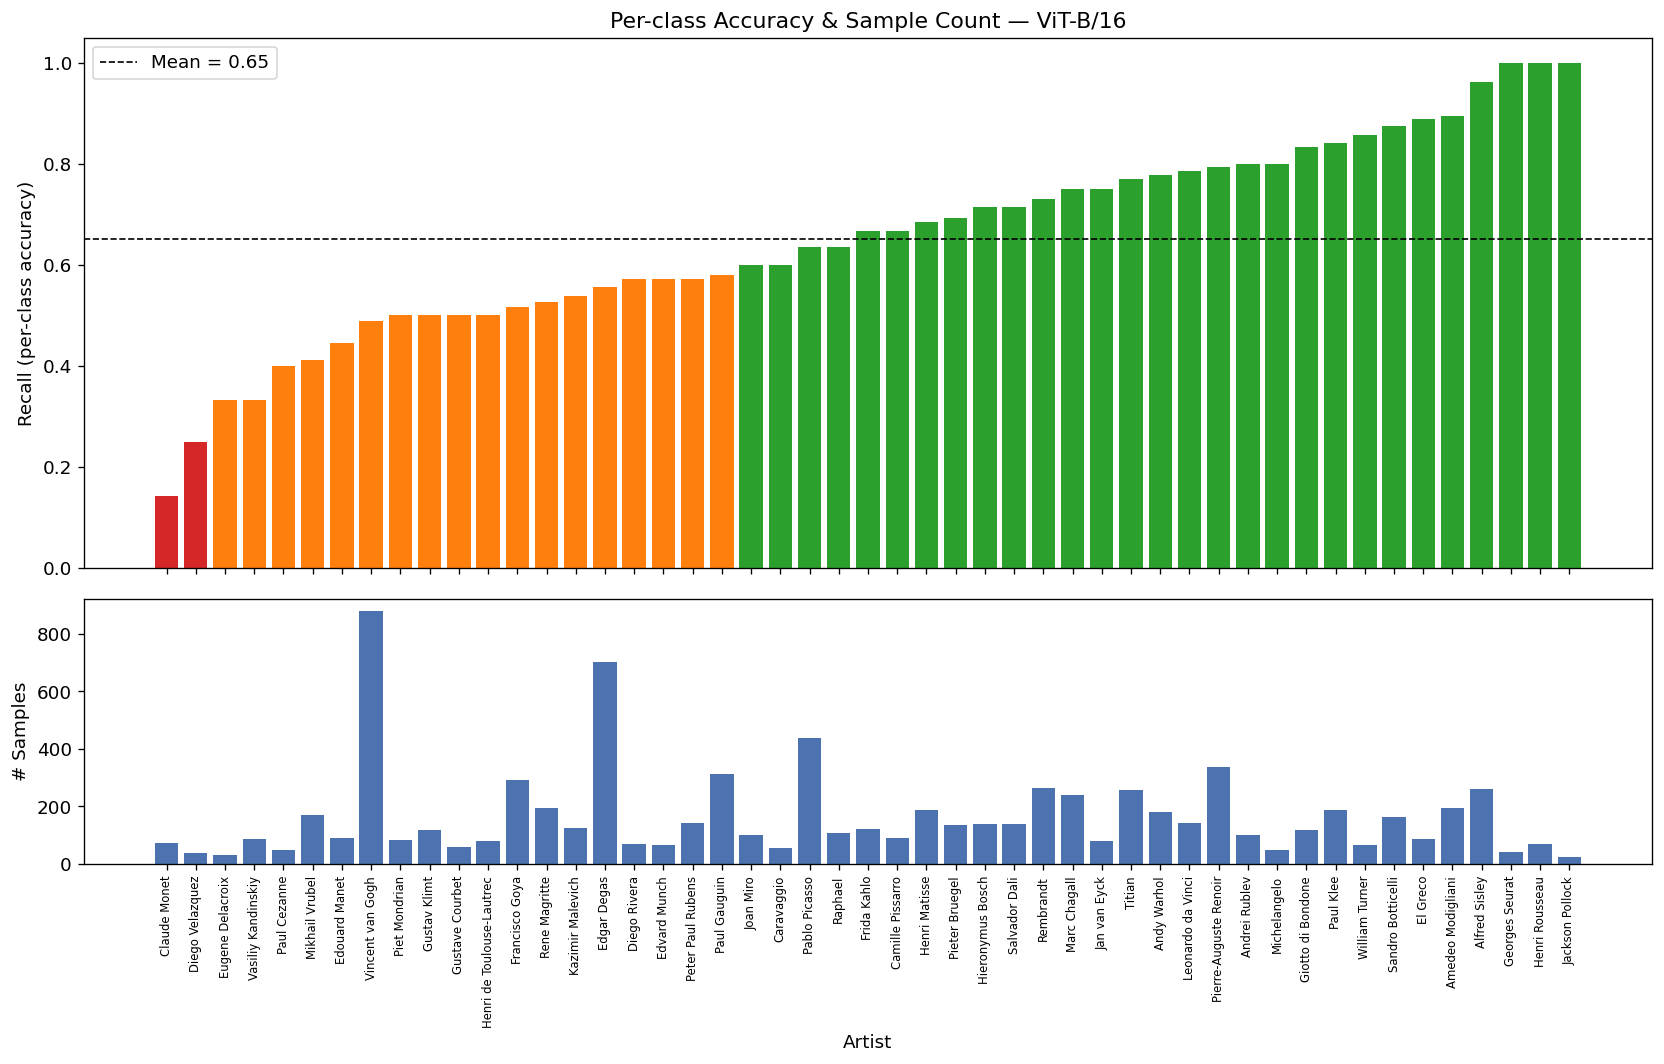

Worst 10 artists:
Claude Monet          0.142857
Diego Velazquez       0.250000
Eugene Delacroix      0.333333
Vasiliy Kandinskiy    0.333333
Paul Cezanne          0.400000
Mikhail Vrubel        0.411765
Edouard Manet         0.444444
Vincent van Gogh      0.488636
Piet Mondrian         0.500000
Gustav Klimt          0.500000

Best 10 artists:
Giotto di Bondone    0.833333
Paul Klee            0.842105
William Turner       0.857143
Sandro Botticelli    0.875000
El Greco             0.888889
Amedeo Modigliani    0.894737
Alfred Sisley        0.961538
Georges Seurat       1.000000
Henri Rousseau       1.000000
Jackson Pollock      1.000000


In [ ]:
# ---- 2. Per-class accuracy bar chart + sample count (shared x-axis) ----
report_best = classification_report(
    best_true, best_preds, target_names=le.classes_, output_dict=True)
per_class_acc = pd.Series(
    {cls: report_best[cls]["recall"] for cls in le.classes_}
).sort_values()

# Sample counts per class (full dataset)
label_series = pd.Series(all_labels)
sample_counts = label_series.value_counts().reindex(per_class_acc.index)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9),
                                sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
fig.subplots_adjust(hspace=0.05)

# Top: per-class accuracy
colors = ["#d62728" if v < 0.3 else "#ff7f0e" if v < 0.6 else "#2ca02c"
          for v in per_class_acc]
ax1.bar(per_class_acc.index, per_class_acc.values, color=colors, edgecolor="none")
ax1.axhline(per_class_acc.mean(), color="black", linestyle="--", linewidth=1,
            label=f"Mean = {per_class_acc.mean():.2f}")
ax1.set_ylabel("Recall (per-class accuracy)")
ax1.set_title(f"Per-class Accuracy & Sample Count — {best_name}")
ax1.legend()
ax1.set_ylim(0, 1.05)

# Bottom: sample count
ax2.bar(sample_counts.index, sample_counts.values, color="#4C72B0", edgecolor="none")
ax2.set_ylabel("# Samples")
ax2.set_xlabel("Artist")
plt.xticks(rotation=90, fontsize=7)

plt.tight_layout()
plt.show()

print("Worst 10 artists:")
print(per_class_acc.head(10).to_string())
print("\nBest 10 artists:")
print(per_class_acc.tail(10).to_string())


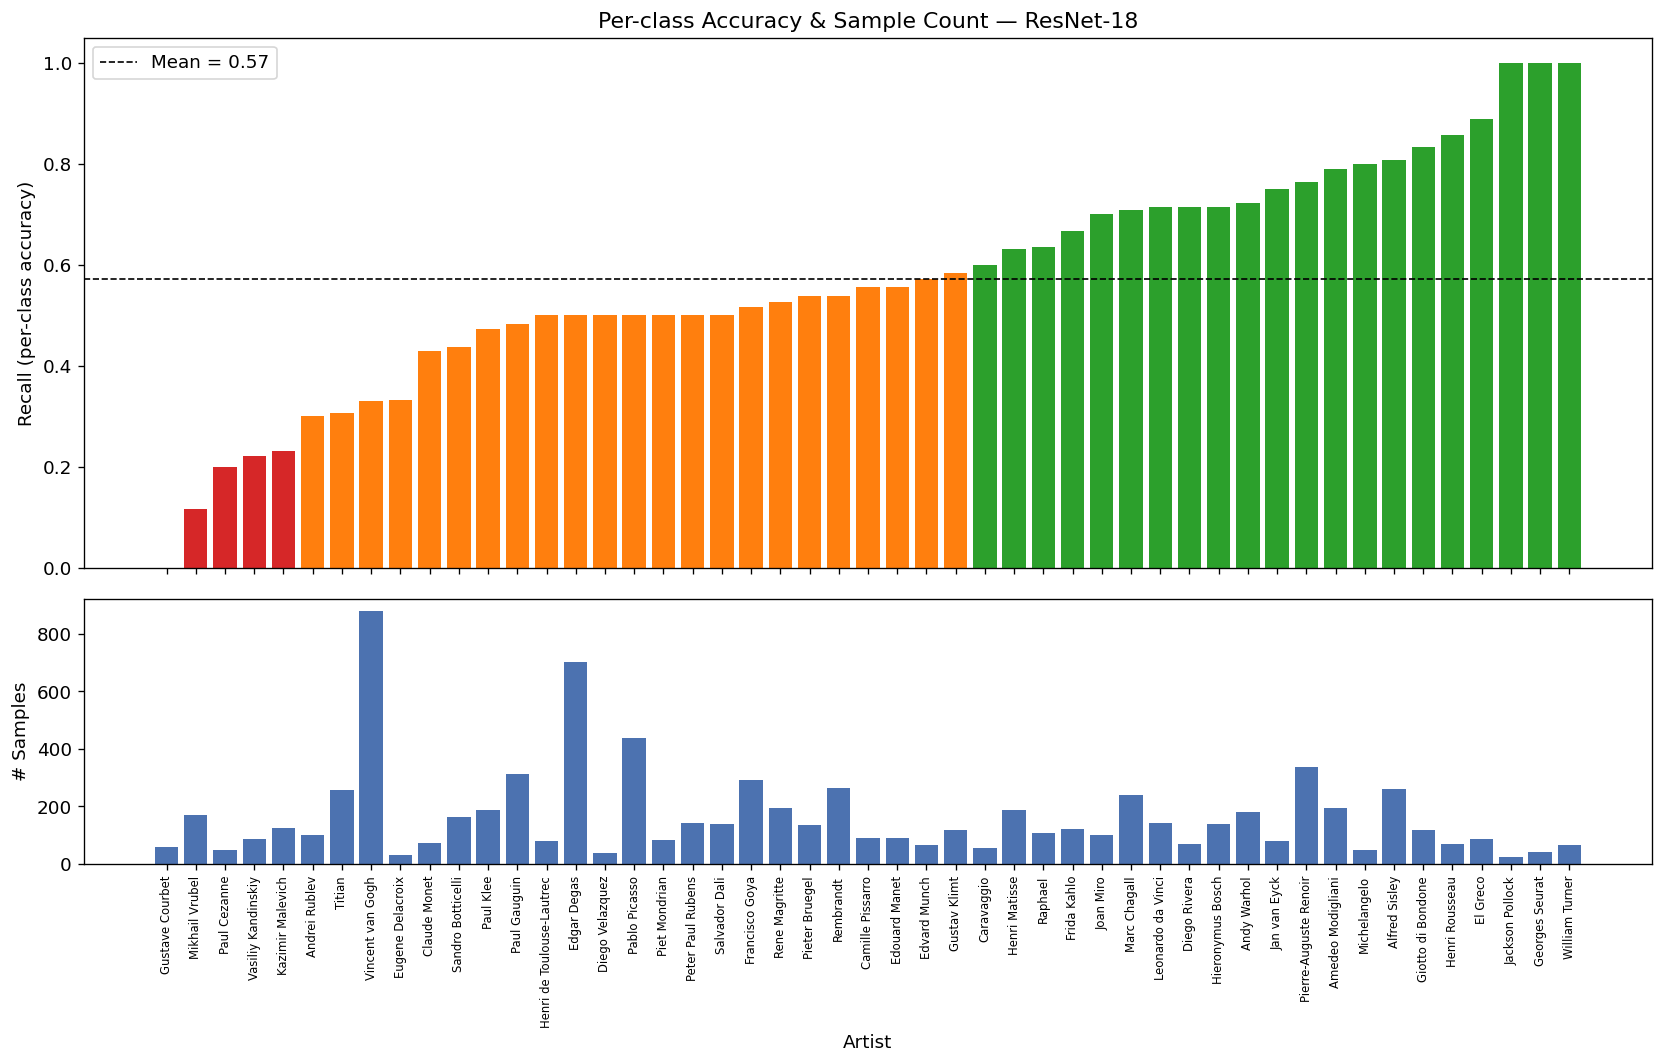

Worst 10 artists (ResNet-18):
Gustave Courbet       0.000000
Mikhail Vrubel        0.117647
Paul Cezanne          0.200000
Vasiliy Kandinskiy    0.222222
Kazimir Malevich      0.230769
Andrei Rublev         0.300000
Titian                0.307692
Vincent van Gogh      0.329545
Eugene Delacroix      0.333333
Claude Monet          0.428571

Best 10 artists (ResNet-18):
Pierre-Auguste Renoir    0.764706
Amedeo Modigliani        0.789474
Michelangelo             0.800000
Alfred Sisley            0.807692
Giotto di Bondone        0.833333
Henri Rousseau           0.857143
El Greco                 0.888889
Jackson Pollock          1.000000
Georges Seurat           1.000000
William Turner           1.000000


In [ ]:
# ---- 2b. Same plot for ResNet-18 ----
report_resnet = classification_report(
    resnet_true, resnet_preds, target_names=le.classes_, output_dict=True)
per_class_acc_resnet = pd.Series(
    {cls: report_resnet[cls]["recall"] for cls in le.classes_}
).sort_values()

sample_counts_resnet = label_series.value_counts().reindex(per_class_acc_resnet.index)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9),
                                sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
fig.subplots_adjust(hspace=0.05)

colors = ["#d62728" if v < 0.3 else "#ff7f0e" if v < 0.6 else "#2ca02c"
          for v in per_class_acc_resnet]
ax1.bar(per_class_acc_resnet.index, per_class_acc_resnet.values, color=colors, edgecolor="none")
ax1.axhline(per_class_acc_resnet.mean(), color="black", linestyle="--", linewidth=1,
            label=f"Mean = {per_class_acc_resnet.mean():.2f}")
ax1.set_ylabel("Recall (per-class accuracy)")
ax1.set_title("Per-class Accuracy & Sample Count — ResNet-18")
ax1.legend()
ax1.set_ylim(0, 1.05)

ax2.bar(sample_counts_resnet.index, sample_counts_resnet.values, color="#4C72B0", edgecolor="none")
ax2.set_ylabel("# Samples")
ax2.set_xlabel("Artist")
plt.xticks(rotation=90, fontsize=7)

plt.tight_layout()
plt.show()

print("Worst 10 artists (ResNet-18):")
print(per_class_acc_resnet.head(10).to_string())
print("\nBest 10 artists (ResNet-18):")
print(per_class_acc_resnet.tail(10).to_string())


In [ ]:
# ---- 3. Sample failure gallery ----
# We need softmax confidence scores — re-run inference, keeping probabilities

# Determine which model object to use
model_obj_map = {
    "ResNet-18":         model,
    "EfficientNet-B0":   eff_model,
    "ViT-B/16":          vit_model,
    "CLIP Linear Probe": clip_probe,
}
best_model_obj = model_obj_map[best_name]

# Collect (path, true_label, pred_label, confidence) for all failures
best_model_obj.eval()
fail_records = []  # (path, true_idx, pred_idx, conf)
idx_offset = 0
with torch.no_grad():
    for imgs, labels in DataLoader(
            ArtDataset(X_test, y_test, val_tf), batch_size=64, shuffle=False, num_workers=0):
        probs = torch.softmax(best_model_obj(imgs.to(device)), dim=1).cpu().numpy()
        preds_b = probs.argmax(axis=1)
        for i, (pred, true) in enumerate(zip(preds_b, labels.numpy())):
            if pred != true:
                fail_records.append((
                    X_test[idx_offset + i],
                    true, pred,
                    probs[i, pred]
                ))
        idx_offset += len(labels)

# Sort by confidence descending (model is most "sure" but wrong)
fail_records.sort(key=lambda x: -x[3])

N_SHOW = 20
ncols = 5
nrows = N_SHOW // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3.5))
axes = axes.flatten()

for ax, (path, true_idx, pred_idx, conf) in zip(axes, fail_records[:N_SHOW]):
    img = Image.open(path).convert("RGB").resize((224, 224))
    ax.imshow(img)
    ax.set_title(
        f"True: {le.classes_[true_idx]}\nPred: {le.classes_[pred_idx]}\n(conf {conf:.2f})",
        fontsize=7, color="red"
    )
    ax.axis("off")

for ax in axes[N_SHOW:]:
    ax.axis("off")

plt.suptitle(f"Top-{N_SHOW} High-Confidence Failures — {best_name}", fontsize=12)
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.